In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
# budowa pipeline
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.compose import ColumnTransformer

# preprocessong
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, PowerTransformer
# redukcja wymiarowości
from sklearn.decomposition import PCA
# model
from sklearn.linear_model import LogisticRegression
# ewaluacja
from calculate_metrics import calculate_metrics

In [2]:
dataset = pd.read_csv('diabetes.csv')
dataset = dataset.drop(['PatientID'], axis=1)
X = dataset.drop(['Diabetic'], axis=1).copy()
y = dataset['Diabetic'].copy()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
print(X_train.isnull().mean())

Pregnancies               0.0
PlasmaGlucose             0.0
DiastolicBloodPressure    0.0
TricepsThickness          0.0
SerumInsulin              0.0
BMI                       0.0
DiabetesPedigree          0.0
Age                       0.0
dtype: float64


Tutaj zbiór nie zawierał pustych wartości i nie stwierdziłem też wartości kategorycznych.
Model z pipeline.

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      2500
           1       0.74      0.57      0.64      1250

    accuracy                           0.79      3750
   macro avg       0.77      0.73      0.75      3750
weighted avg       0.78      0.79      0.78      3750



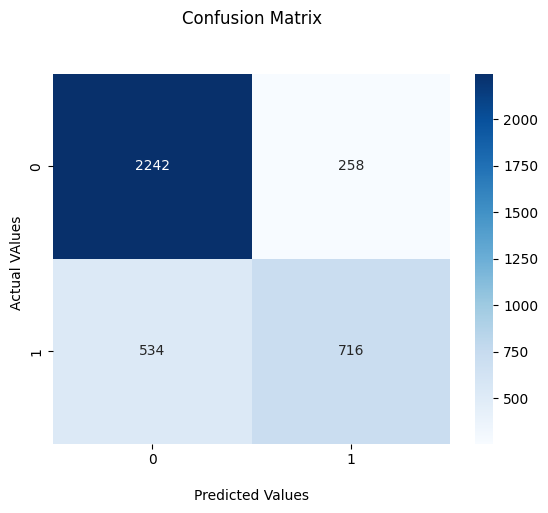

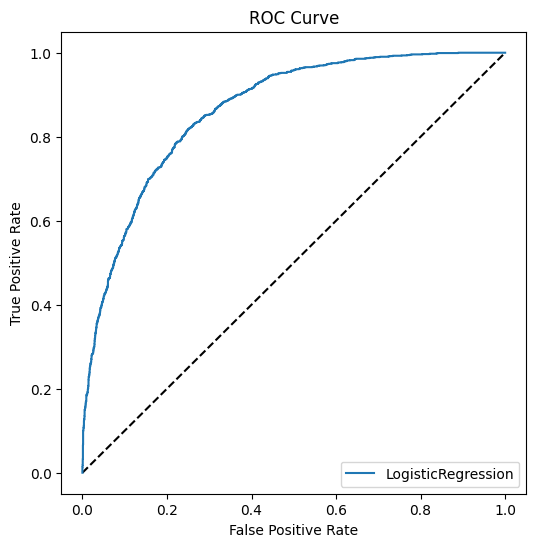

,Model,F1_score,AUC
0,LogisticRegression,0.643885,0.864158


In [3]:
num_features = ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']

# przygotowanie wartości numerycznych
num_preparation = Pipeline(steps=[
    ('fill_missings', SimpleImputer(strategy='mean')),
    ('polynomial_features', PolynomialFeatures(degree=3)),
    ('scaler_1', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('scaler_2', StandardScaler())
])

# transformer wartości numeryczne
data_preparation = ColumnTransformer(transformers=[
    ('numeric_preprocessing', num_preparation, num_features),
])

model_pipeline_v2 = Pipeline(steps=[('preprocessor', data_preparation),
                                    ('model', LogisticRegression(max_iter=10000))])
model_pipeline_v2.fit(X_train, y_train)
calculate_metrics(model_pipeline_v2, 'LogisticRegression', X_test, y_test)

Model bez pipeline z poprzedniego ćwiczenia

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      2500
           1       0.69      0.66      0.67      1250

    accuracy                           0.79      3750
   macro avg       0.76      0.76      0.76      3750
weighted avg       0.79      0.79      0.79      3750



c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


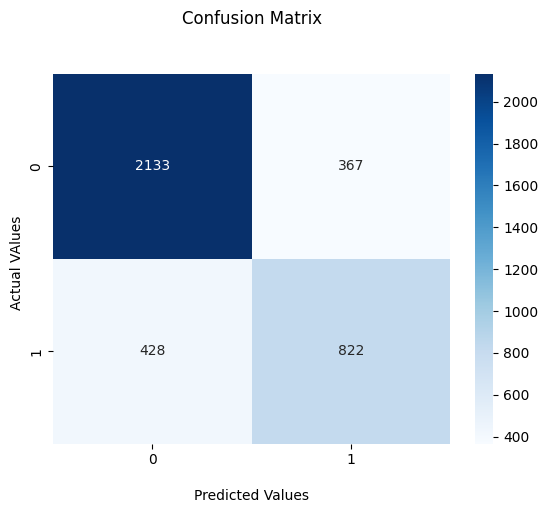

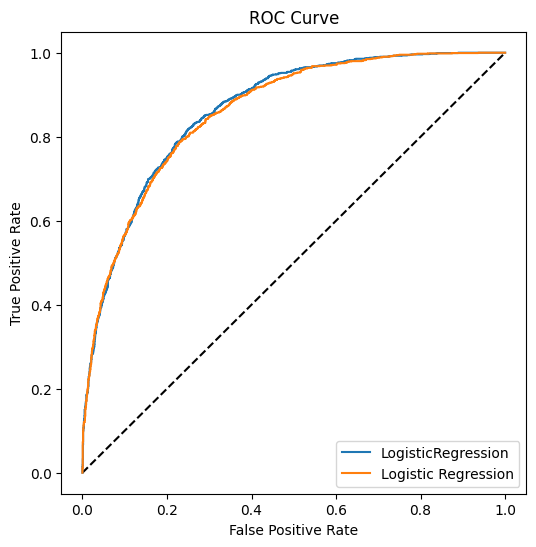

,Model,F1_score,AUC
0,LogisticRegression,0.643885,0.864158
1,Logistic Regression,0.674047,0.859939


In [4]:
scaler_2var = StandardScaler()
X_train_standardized = scaler_2var.fit_transform(X_train)
X_test_standardized = scaler_2var.transform(X_test)

model = LogisticRegression(
        penalty='l2',
        C=0.00001,
        solver='liblinear'
    )

model.fit(X_train_standardized, y_train)
calculate_metrics(model, 'Logistic Regression', X_test_standardized, y_test)

Poprzedni model ma lepszy F1_score ale dlatego że był ręcznie strojony, ten z pipeline korzysta z domyślnych wartości LogisticRegression i tak wartość AUC jest minimalnie lepsza.

Fitting 5 folds for each of 560 candidates, totalling 2800 fits
Wybrane hiperparametry:  {'model__C': 0.046415888336127774, 'preprocessor__numeric_preprocessing__fill_missings__strategy': 'mean', 'preprocessor__numeric_preprocessing__pca__n_components': None, 'preprocessor__numeric_preprocessing__polynomial_features__degree': 4}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      2500
           1       0.87      0.85      0.86      1250

    accuracy                           0.91      3750
   macro avg       0.90      0.89      0.89      3750
weighted avg       0.91      0.91      0.91      3750



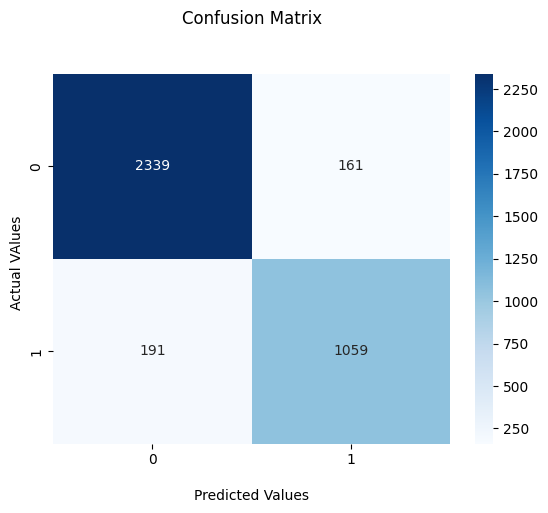

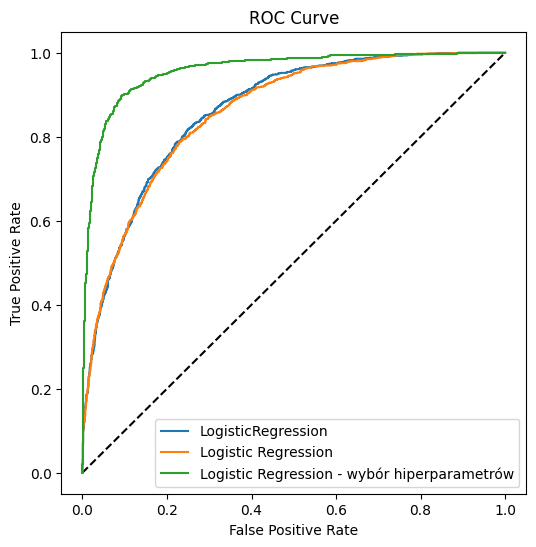

,Model,F1_score,AUC
0,LogisticRegression,0.643885,0.864158
1,Logistic Regression,0.674047,0.859939
2,Logistic Regression - wybór hiperparametrów,0.857490,0.957746


In [5]:
model_pipeline_v3 = Pipeline(steps=[('preprocessor', data_preparation),
                                    ('model', LogisticRegression(max_iter=10000))])
params = [{
    'preprocessor__numeric_preprocessing__fill_missings__strategy':['mean','median'],
    'preprocessor__numeric_preprocessing__polynomial_features__degree':[1,2,3,4],
    'preprocessor__numeric_preprocessing__pca__n_components':[0.75,0.85,0.90,0.95,0.99,0.99999,None],
    'model__C':np.logspace(-4,4,10)
}]
grid_search = GridSearchCV(model_pipeline_v3,params, cv=5,n_jobs=-1,verbose=5, scoring='f1_macro')
grid_search.fit(X_train,y_train)
print('Wybrane hiperparametry: ', grid_search.best_params_)
model_v3 = grid_search.best_estimator_
calculate_metrics(model_v3, 'Logistic Regression - wybór hiperparametrów', X_test, y_test)

I tutaj już widać sporą przewagę modelu nad pozostałymi wcześniejszymi modelami. Dużo wyższe F1_score i AUC. Przy uwzględnieniu None wynik się jeszcze poprawił (F1=0.844855 oraz AUC = 0.951638 dla 0.99999).Redukcja danych PCA tutaj nie poprawia działania modelu.

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Wybrane hiperparametry:  {'model__C': 1291.5496650148827, 'preprocessor__numeric_preprocessing__fill_missings__strategy': 'mean', 'preprocessor__numeric_preprocessing__pca': 'passthrough', 'preprocessor__numeric_preprocessing__polynomial_features__degree': 4}
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      2500
           1       0.85      0.84      0.85      1250

    accuracy                           0.90      3750
   macro avg       0.89      0.88      0.88      3750
weighted avg       0.90      0.90      0.90      3750



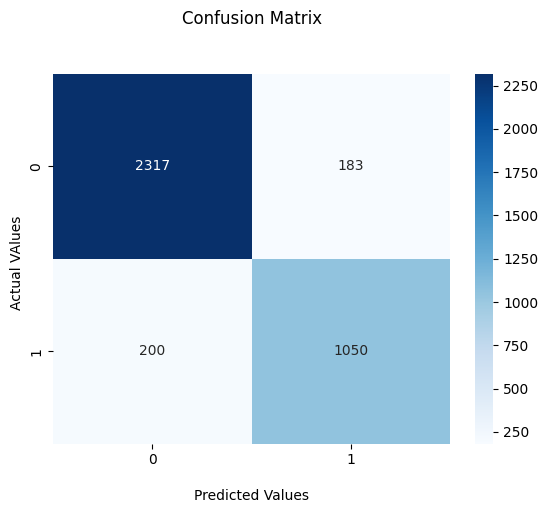

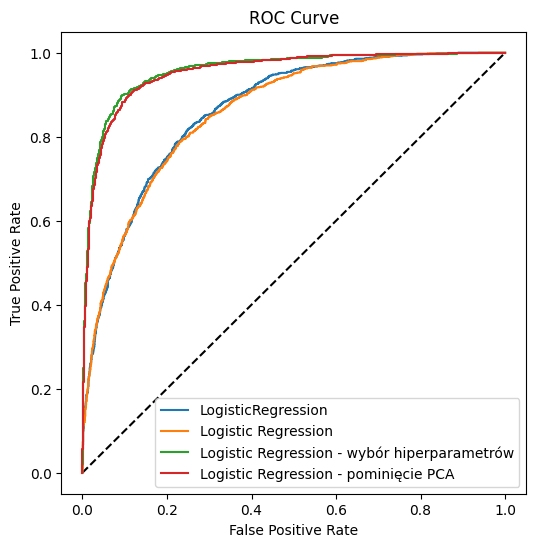

,Model,F1_score,AUC
0,LogisticRegression,0.643885,0.864158
1,Logistic Regression,0.674047,0.859939
2,Logistic Regression - wybór hiperparametrów,0.857490,0.957746
3,Logistic Regression - pominięcie PCA,0.845751,0.954564


In [6]:
model_pipeline_v3 = Pipeline(steps=[('preprocessor', data_preparation),
                                    ('model', LogisticRegression(max_iter=10000))])
params = {
    'preprocessor__numeric_preprocessing__fill_missings__strategy':['mean','median'],
    'preprocessor__numeric_preprocessing__polynomial_features__degree':[1,2,3,4],
    'preprocessor__numeric_preprocessing__pca': ['passthrough'],
    'model__C':np.logspace(-4,4,10)
}
grid_search = GridSearchCV(model_pipeline_v3,params, cv=5,n_jobs=-1,verbose=5, scoring='f1_macro')
grid_search.fit(X_train,y_train)
print('Wybrane hiperparametry: ', grid_search.best_params_)
model_v3 = grid_search.best_estimator_
calculate_metrics(model_v3, 'Logistic Regression - pominięcie PCA', X_test, y_test)

Tutaj generalnie przy tych danych ja nie widzę wielkiego pola do uwspólniania osi bo w sumie dane raczej nie odzwierciedlają podobnych cech czy współzależnych. Brak PCA wydłuża czas nauki i wynik jest słabszy. Polynominal tworzy nowe kolumny więc przekształcenie cech przez PCA prawdopodobnie pomaga modelowi a wynik jest najlepszy dla PCA bez redukcji liczby składowych.